# Multivariate Probit Regression

For $i=1,\ldots,n$, the observation $Y_i\in \{0,1\}^{J}$ is given by
$$
Y_{ij}=1\{Z_{ij} > 0 \},\quad Z_i=(Z_{i1},\ldots,Z_{iJ})^\top \sim N(\mu_i, \Sigma),\quad \mu_{ij}=X_{ij}^\top \beta
$$
where $X_{ij}\in R^d,\beta\in R^d$, and $\Sigma$ is a correlation matrix.

Let $s_{i}=2y_{i}-1$. Then
$$
P(Y_i=y_i\mid X_i,\beta,\Sigma)= \int_{\text{sign}(z) = s_i } \varphi(z\mid \mu_i,\Sigma ) dz.
$$

- Gibbs: sequentially update $\beta,Z,\Sigma$; might need MH with Gibbs.
- NUTS: uses log-transform on $|Z_{ij}|$ to handle sign constraints; uses LKJ to handle correlation matrix.

For now, we use a fixed $\Sigma$ (e.g. AR1). 

In [34]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

from numpyro.infer import HMC, MCMC, NUTS

from src.cauchy_mh import independent_cauchy_mh
from src.scp_core import SCP
from experiments.targets import MultivariateProbitPosterior
from experiments.run_probit import build_dataset

### Generate synthetic data and setup target distribution

In [2]:
cfg = {
    "n": 5,
    "J": 3,
    "p": 3,
    "rho": 0.7,
    "prior_df": 2.0,
    "prior_scale": 2.5,
    "n_nonzero": 5,
    "signal": .5,
    "seed": 0
}

X, y, beta_true = build_dataset(
    n=cfg["n"],
    J=cfg["J"],
    p=cfg["p"],
    rho=cfg["rho"],
    n_nonzero=cfg["n_nonzero"],
    signal=cfg["signal"],
    seed=cfg["seed"],
)

target = MultivariateProbitPosterior(
    X,
    y,
    rho=cfg["rho"],
    prior_df=cfg["prior_df"],
    prior_scale=cfg["prior_scale"],
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("state dimension:", target.d)
print("positive outcomes:", int(jnp.sum(y)))

pd.DataFrame({"beta_true": beta_true})

X shape: (5, 3, 3)
y shape: (5, 3)
state dimension: 18
positive outcomes: 4


,beta_true
0,0.500
1,-0.375
2,0.250


### NUTS

In [3]:
nuts_kernel = NUTS(potential_fn=lambda state: -target.log_prob(state))
nuts_mcmc = MCMC(
    nuts_kernel,
    num_warmup=100,
    num_samples=2000,
    thinning=1,
    num_chains=1,
)
nuts_mcmc.run(
    jax.random.key(1),
    init_params=target.initial_state(),
    extra_fields=("accept_prob",),
)

nuts_samples = nuts_mcmc.get_samples()
nuts_beta_samples = target.extract_beta(nuts_samples)
nuts_z_samples = target.latent_from_state(nuts_samples)
nuts_accept_rate = jnp.mean(nuts_mcmc.get_extra_fields()["accept_prob"])

print("NUTS acceptance rate:", float(nuts_accept_rate))
print("NUTS sample shape:", nuts_samples.shape)
print("NUTS beta sample shape:", nuts_beta_samples.shape)
print("NUTS latent sign constraints satisfied:", bool(jnp.all(target.side[None, :, :] * nuts_z_samples > 0.0)))

sample: 100%|██████████| 2100/2100 [00:00<00:00, 3105.88it/s, 31 steps of size 1.42e-01. acc. prob=0.92]


NUTS acceptance rate: 0.9176687002182007
NUTS sample shape: (2000, 18)
NUTS beta sample shape: (2000, 3)
NUTS latent sign constraints satisfied: True


### HMC

In [4]:
hmc_kernel = HMC(
    potential_fn=lambda state: -target.log_prob(state),
    step_size=0.1,
    adapt_step_size=True,
    adapt_mass_matrix=False,
    num_steps=10,
    trajectory_length=None,
)
hmc_mcmc = MCMC(
    hmc_kernel,
    num_warmup=100,
    num_samples=2000,
    thinning=1,
    num_chains=1,
)
hmc_mcmc.run(
    jax.random.key(1),
    init_params=target.initial_state(),
    extra_fields=("accept_prob",),
)

hmc_samples = hmc_mcmc.get_samples()
hmc_beta_samples = target.extract_beta(hmc_samples)
hmc_z_samples = target.latent_from_state(hmc_samples)
hmc_accept_rate = jnp.mean(hmc_mcmc.get_extra_fields()["accept_prob"])

print("HMC acceptance rate:", float(hmc_accept_rate))
print("HMC sample shape:", hmc_samples.shape)
print("HMC beta sample shape:", hmc_beta_samples.shape)
print("HMC latent sign constraints satisfied:", bool(jnp.all(target.side[None, :, :] * hmc_z_samples > 0.0)))

sample: 100%|██████████| 2100/2100 [00:00<00:00, 4611.10it/s, 10 steps of size 1.40e-01. acc. prob=0.81]

HMC acceptance rate: 0.8124389052391052
HMC sample shape: (2000, 18)
HMC beta sample shape: (2000, 3)
HMC latent sign constraints satisfied: True


In [17]:
cauchy_samples, cauchy_accept_rate = independent_cauchy_mh(
    target.log_prob,
    target.initial_state(),
    jax.random.key(2),
    nsample=2000,
    burnin=100,
    thinning=1,
    stepsize=.5,
)

cauchy_beta_samples = target.extract_beta(cauchy_samples)
cauchy_z_samples = target.latent_from_state(cauchy_samples)

print("Independent Cauchy MH acceptance rate:", float(cauchy_accept_rate))
print("Independent Cauchy MH sample shape:", cauchy_samples.shape)
print("Independent Cauchy MH beta sample shape:", cauchy_beta_samples.shape)
print("Independent Cauchy MH latent sign constraints satisfied:", bool(jnp.all(target.side[None, :, :] * cauchy_z_samples > 0.0)))

pd.DataFrame({
    "beta_true": beta_true,
    "cauchy_beta_mean": jnp.mean(cauchy_beta_samples, axis=0),
    "cauchy_beta_median": jnp.median(cauchy_beta_samples, axis=0),
})

Running for 2,100 iterations: 100%|██████████| 2100/2100 [00:00<00:00, 65424.53it/s]

Independent Cauchy MH acceptance rate: 0.010000000707805157
Independent Cauchy MH sample shape: (2000, 18)
Independent Cauchy MH beta sample shape: (2000, 3)
Independent Cauchy MH latent sign constraints satisfied: True


,beta_true,cauchy_beta_mean,cauchy_beta_median
0,0.500,-0.190839,-0.290669
1,-0.375,-0.215168,-0.129682
2,0.250,-0.132033,-0.005657


### SCP

In [18]:
scp_model = SCP(d=target.d, 
                latitude=1.7, 
                affine='covariance')

opt_params, losses = scp_model.minimize_reverse_kl(
    target.log_prob,
    seed=1,
    ntrain=256,
    max_iter=500,
    learning_rate=1e-3,
    clip_value=10,
    grad_clip_norm=10,
)

print("final loss:", float(losses[-1]))

Running for 500 iterations: 100%|██████████| 500/500 [00:00<00:00, 9321.75it/s]

final loss: -4.203226566314697


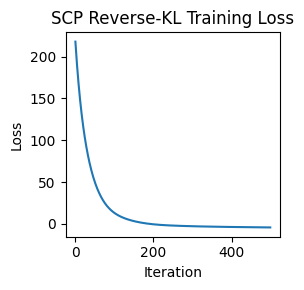

In [19]:
plt.figure(figsize=(3, 3))
plt.plot(losses)
plt.title("SCP Reverse-KL Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [20]:
scp_samples = scp_model.sample(opt_params, jax.random.key(2), n=1000)
scp_beta_samples = target.extract_beta(scp_samples)

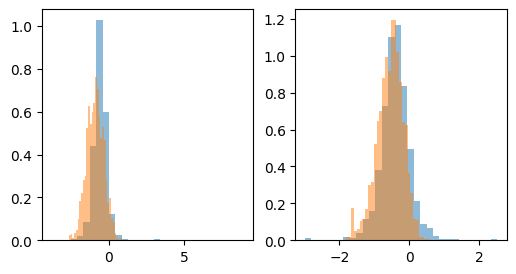

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for j in range(2):
    ax[j].hist(scp_beta_samples[:, j].clip(-10, 10), density=True, bins=30, alpha=0.5, label="SCP")
    ax[j].hist(hmc_beta_samples[:, j], density=True, bins=30, alpha=0.5, label="NUTS")

In [22]:
u0 = scp_model.inverse_projection(opt_params, target.initial_state())
reprojected_state = scp_model.projection(opt_params, u0)
print("sphere state shape:", u0.shape)
print("reprojected log_prob:", float(target.log_prob(reprojected_state)))
print("reprojected latent signs valid:", bool(jnp.all(target.side * target.latent_from_state(reprojected_state) > 0.0)))

sphere state shape: (19,)
reprojected log_prob: -8.562347412109375
reprojected latent signs valid: True


In [23]:
scp_samples, scp_accept_prob = scp_model.rwm_bright_side(
    target.log_prob,
    opt_params,
    seed=1,
    x0=u0,
    stepsize=0.1,
    nsample=10000,
    burnin=100,
    thinning=5,
    algo="stepout",
)

scp_rwm_beta_samples = target.extract_beta(scp_samples)
scp_rwm_z_samples = target.latent_from_state(scp_samples)

print("acceptance rate:", float(scp_accept_prob))
print("sample shape:", scp_samples.shape)
print("beta sample shape:", scp_rwm_beta_samples.shape)
print("latent sign constraints satisfied across all samples:", bool(jnp.all(target.side[None, :, :] * scp_rwm_z_samples > 0.0)))

Running for 10,100 iterations: 100%|██████████| 10100/10100 [00:00<00:00, 98725.39it/s]


acceptance rate: 0.19600000977516174
sample shape: (2000, 18)
beta sample shape: (2000, 3)
latent sign constraints satisfied across all samples: True


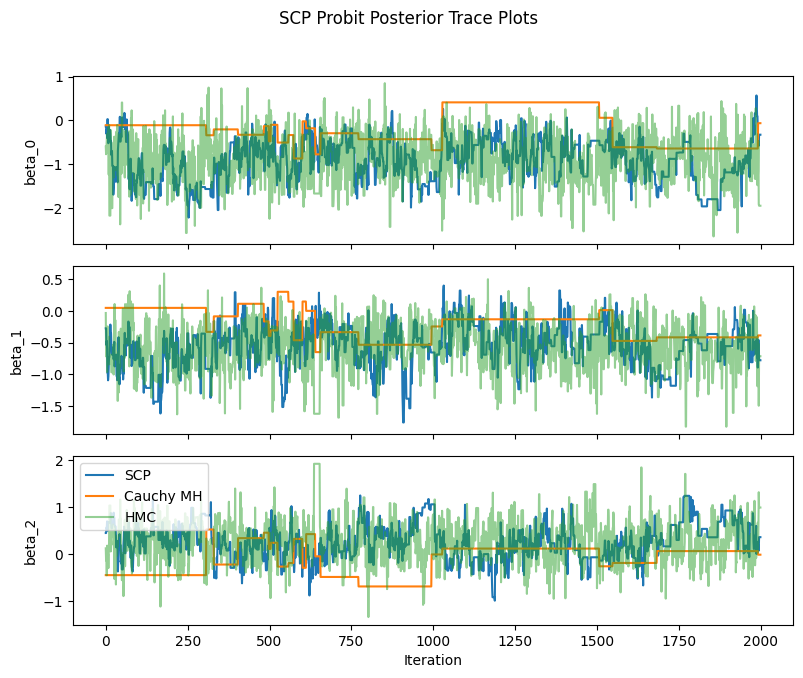

In [30]:
nplot = min(4, scp_rwm_beta_samples.shape[1])
fig, axes = plt.subplots(nplot, 1, figsize=(8, 2.2 * nplot), sharex=True)
if nplot == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    ax.plot(scp_rwm_beta_samples[:, j], label="SCP")
    ax.plot(cauchy_beta_samples[:, j], label="Cauchy MH")
    ax.plot(hmc_beta_samples[:, j], alpha=0.5, label="HMC")
    ax.set_ylabel(f"beta_{j}")

axes[-1].legend(loc="upper left")
axes[-1].set_xlabel("Iteration")
fig.suptitle("SCP Probit Posterior Trace Plots", y=1.02)
plt.tight_layout()
plt.show()

$\beta$ samples

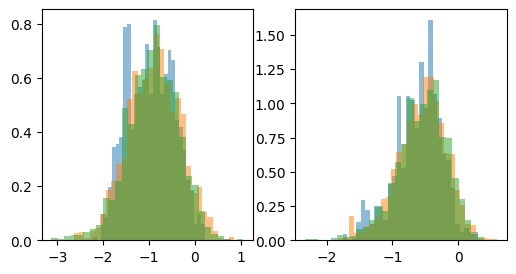

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for j in range(2):
    ax[j].hist(scp_rwm_beta_samples[:-1000, j], density=True, bins=30, alpha=0.5, label="SCP")
    ax[j].hist(hmc_beta_samples[:, j], density=True, bins=30, alpha=0.5, label="HMC")
    ax[j].hist(nuts_beta_samples[:, j], density=True, bins=30, alpha=0.5, label="NUTS")

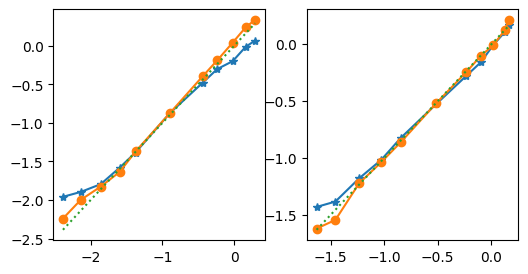

In [32]:
ps = jnp.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.98, 0.99])

def plot_quantiles(samples, ax):
    qs = jnp.quantile(samples, ps)
    ax.plot(ps, qs)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for j in range(2):
    nuts_quantiles = jnp.quantile(nuts_beta_samples[:, j], ps)
    scp_quantiles = jnp.quantile(scp_rwm_beta_samples[:, j], ps)
    hmc_quantiles = jnp.quantile(hmc_beta_samples[:, j], ps)
    ax[j].plot(nuts_quantiles, scp_quantiles, "*-")
    ax[j].plot(nuts_quantiles, hmc_quantiles, "o-")
    ax[j].plot(nuts_quantiles, nuts_quantiles, ":")


HMC seems work well. Independent Cauchy proposal doesn't work well.

Latent variable (Z) samples

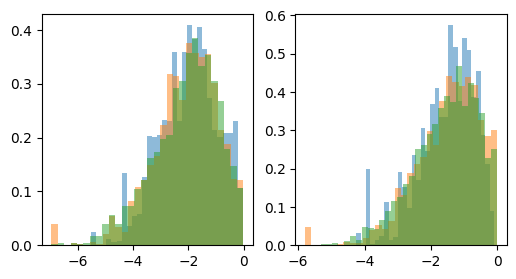

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for j in range(2):
    ax[j].hist(scp_rwm_z_samples[:, 0, j], density=True, bins=30, alpha=0.5, label="SCP")
    ax[j].hist(hmc_z_samples[:, 0, j], density=True, bins=30, alpha=0.5, label="HMC")
    ax[j].hist(nuts_z_samples[:, 0, j], density=True, bins=30, alpha=0.5, label="NUTS")